# Real FFT — `fft.h`: verification & findings

The shared real FFT, measured. Like the other Tap notebooks, every cell drives the **actual
shipping DSP** — `tap::dsp::basic_real_fft<double>` and `<float>`, the same header the consuming
libraries compile — through the C ABI in `tools/capi/` (`dsptap_fft_*`), loaded via ctypes
(`dsptap_py.RealFFT`). Nothing here is a Python re-implementation of the transform; the one
external reference is `numpy.fft.rfft`, used as the oracle for the packing and sign convention.

Contents:

1. **Packing and sign convention** — the header's packed layout, and the conjugate relation to
   the engineering-convention DFT (`numpy.fft.rfft`), demonstrated bin for bin.
2. **Float vs double** — per-bin relative error of the float32 profile against the double golden
   model, as a function of N, on the profile's own arithmetic (no double round trip).
3. **Round trip** — `forward → inverse` reconstruction error vs N for both profiles.
4. **Fixed point (Stage 3b/3c) — placeholder.** What the Q15/Q31 noise-floor curves will
   measure, and why; no data until the kernel lands.

Both profiles run Ooura on the host that executed this notebook (the backend is printed in the
setup cell); on macOS the float profile rides vDSP and on the M55 CMSIS-Helium, and the same
cells then measure that backend. This notebook is committed **executed**, per the house rule
(CLAUDE.md, *Verification layer*); re-execute with
`jupyter nbconvert --to notebook --execute --inplace notebooks/fft.ipynb` after any change to
`fft.h`.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

import dsptap_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
rng = np.random.default_rng(20260917)

EPS32, EPS64 = np.finfo(np.float32).eps, np.finfo(np.float64).eps
SIZES = [2 ** k for k in range(3, 17)]   # 8 .. 65536

print(f"host: {platform.system()} {platform.machine()}, numpy {np.__version__}")
print(f"float32 FFT backend compiled into dsptap_capi: {tap.RealFFT.backend()!r} (double is always Ooura)")
f = tap.RealFFT(512, "double")
print(f"RealFFT(512): size {f.size}, num_bins {f.num_bins}, profile {f.profile}, native dtype {f.dtype}")
print(f"RealFFT(512, 'float').dtype = {tap.RealFFT(512, 'float').dtype}")

host: Linux x86_64, numpy 2.4.6
float32 FFT backend compiled into dsptap_capi: 'ooura' (double is always Ooura)
RealFFT(512): size 512, num_bins 257, profile double, native dtype float64
RealFFT(512, 'float').dtype = float32


## 1 · Packing and sign convention, against `numpy.fft.rfft`

`fft.h`'s contract for a forward transform of N real samples, packed into N reals:

- `data[0]` = DC (real), `data[1]` = Nyquist (real) — their imaginary parts are zero for a real
  signal and are not stored;
- `data[2k] + i·data[2k+1]` = bin k for 1 ≤ k < N/2;
- the kernel is W = exp(**+**2πi/N), so every imaginary part is **conjugated** relative to the
  engineering-convention DFT (exp(−2πi/N)) that `numpy.fft.rfft` computes.

`RealFFT.unpack` undoes the packing *and* conjugates, so it lands in numpy's convention; the
cell below checks all three points bin for bin, and shows the raw (un-conjugated) imaginary
parts mirroring numpy's.

DC:      packed[0] = +4.030030   rfft[0]      = +4.030030 (imag +0.0e+00)
Nyquist: packed[1] = -1.520776   rfft[N/2]    = -1.520776 (imag +0.0e+00)
max |packed_re - rfft_re|   over bins 1..N/2-1: 1.78e-15
max |packed_im - rfft_im|   (same sign):        3.01e+01   <- not equal
max |packed_im - (-rfft_im)| (conjugate):       2.44e-15   <- equal
max |unpack(forward(x)) - rfft(x)|: 2.68e-15
max |pack(unpack(X)) - X|:          0.00e+00


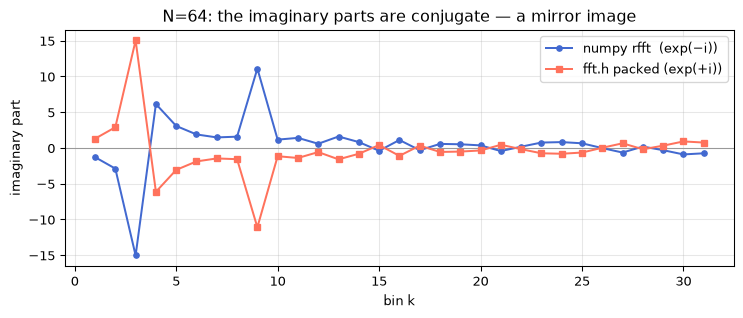

In [2]:
N = 64
n = np.arange(N)
x = np.sin(2 * np.pi * 3.3 * n / N) + 0.5 * np.cos(2 * np.pi * 9 * n / N + 0.7) + 0.1 * rng.standard_normal(N)

fft64 = tap.RealFFT(N, "double")
packed = fft64.forward(x)            # raw Ooura layout, exp(+i) convention
ref = np.fft.rfft(x)                 # engineering convention

# (a) DC and Nyquist sit at data[0] and data[1], real.
print(f"DC:      packed[0] = {packed[0]:+.6f}   rfft[0]      = {ref[0].real:+.6f} (imag {ref[0].imag:+.1e})")
print(f"Nyquist: packed[1] = {packed[1]:+.6f}   rfft[N/2]    = {ref[-1].real:+.6f} (imag {ref[-1].imag:+.1e})")

# (b) Interior bins: real parts agree, imaginary parts are NEGATED.
raw_im = packed[3::2]                # imag of bins 1..N/2-1, Ooura orientation
print(f"max |packed_re - rfft_re|   over bins 1..N/2-1: {np.max(np.abs(packed[2::2] - ref[1:-1].real)):.2e}")
print(f"max |packed_im - rfft_im|   (same sign):        {np.max(np.abs(raw_im - ref[1:-1].imag)):.2e}   <- not equal")
print(f"max |packed_im - (-rfft_im)| (conjugate):       {np.max(np.abs(raw_im + ref[1:-1].imag)):.2e}   <- equal")

# (c) unpack() lands in numpy's convention; pack() is its exact inverse.
print(f"max |unpack(forward(x)) - rfft(x)|: {np.max(np.abs(fft64.unpack(packed) - ref)):.2e}")
print(f"max |pack(unpack(X)) - X|:          {np.max(np.abs(fft64.pack(fft64.unpack(packed)) - packed)):.2e}")

k = np.arange(1, N // 2)
fig, ax = plt.subplots()
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(k, ref[1:-1].imag, "o-", color=C[0], ms=4, lw=1.5, label="numpy rfft  (exp(−i))")
ax.plot(k, raw_im, "s-", color=C[2], ms=4, lw=1.5, label="fft.h packed (exp(+i))")
ax.set(xlabel="bin k", ylabel="imaginary part", title=f"N={N}: the imaginary parts are conjugate — a mirror image")
ax.legend()
plt.show()

## 2 · Float vs double: per-bin relative error vs N

The float32 profile is the embedded profile; the double profile is the golden model. Here the
**same float32-representable input** goes through both — the double transform receives the
float32 values widened, so the comparison isolates the transform's arithmetic and not the input
rounding — and the float profile runs through `forward_inplace_raw` on a float32 buffer, i.e.
`basic_real_fft<float>::forward_inplace` with no conversion anywhere.

Input is white Gaussian noise (unit variance), so no bin is numerically empty and a per-bin
relative error is meaningful. Two statistics are plotted against N: the median and 95th
percentile of |X₃₂[k] − X₆₄[k]| / |X₆₄[k]|, and the whole-spectrum RMS error relative to the
spectrum's RMS — the number a noise-floor budget uses. The dotted guide grows as √log₂N,
anchored at the N = 8 measurement: for floating-point rounding the output noise-to-signal
*power* ratio grows in proportion to the number of stages ν = log₂N (Weinstein, "Roundoff noise
in floating point fast Fourier transform computation," *IEEE Trans. Audio Electroacoust.* 1969;
Oppenheim & Schafer ch. 9), so the RMS error grows as √ν. The worst-case bound ε₃₂·log₂N
(Gentleman & Sande 1966) is printed alongside for scale; the cell also fits the measured
exponent.

     N     median        p95        max    rms rel   (per-bin |X32-X64|/|X64|, white noise)
     8   4.26e-08   9.10e-07   1.12e-06   5.43e-08
    16   7.32e-08   2.29e-07   2.71e-07   6.87e-08
    32   7.70e-08   1.49e-07   2.56e-07   9.18e-08
    64   7.52e-08   2.72e-07   3.30e-07   1.02e-07
   128   1.07e-07   4.04e-07   4.01e-06   1.06e-07
   256   1.17e-07   3.93e-07   1.49e-06   1.17e-07
   512   1.02e-07   4.39e-07   1.27e-06   1.15e-07
  1024   1.20e-07   5.12e-07   9.28e-06   1.20e-07
  2048   1.21e-07   4.88e-07   1.87e-06   1.24e-07
  4096   1.38e-07   5.65e-07   3.98e-06   1.37e-07
  8192   1.39e-07   5.63e-07   1.06e-05   1.40e-07
 16384   1.45e-07   6.03e-07   7.09e-06   1.47e-07
 32768   1.47e-07   6.01e-07   3.08e-05   1.50e-07
 65536   1.53e-07   6.31e-07   4.70e-05   1.54e-07


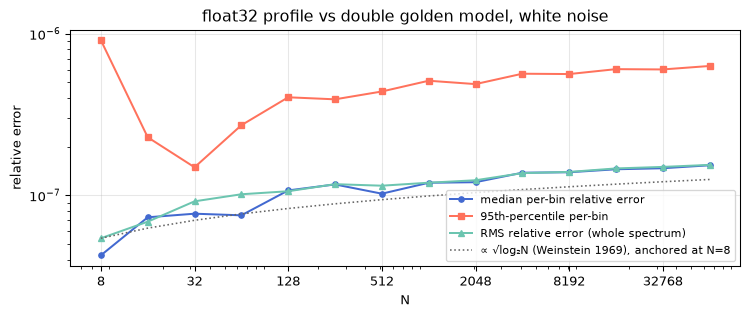

fitted RMS relative error ∝ (log₂N)^0.57   (√ν model predicts 0.50)
at N=65536: measured RMS 1.54e-07 vs worst-case bound ε₃₂·log₂N = 1.91e-06


In [3]:
def float_vs_double(N, x32):
    xd = x32.astype(np.float64)
    Xd = tap.RealFFT(N, "double").unpack(tap.RealFFT(N, "double").forward(xd))
    buf = x32.copy()
    tap.RealFFT(N, "float").forward_inplace_raw(buf)
    Xf = tap.RealFFT.unpack(buf.astype(np.float64))
    rel = np.abs(Xf - Xd) / np.abs(Xd)
    rms = np.linalg.norm(Xf - Xd) / np.linalg.norm(Xd)
    return np.median(rel), np.percentile(rel, 95), np.max(rel), rms

rows = []
for N in SIZES:
    x32 = rng.standard_normal(N).astype(np.float32)
    rows.append((N, *float_vs_double(N, x32)))
rows = np.array(rows)

print(f"{'N':>6} {'median':>10} {'p95':>10} {'max':>10} {'rms rel':>10}   (per-bin |X32-X64|/|X64|, white noise)")
for N, med, p95, mx, rms in rows:
    print(f"{int(N):>6} {med:10.2e} {p95:10.2e} {mx:10.2e} {rms:10.2e}")

fig, ax = plt.subplots()
Ns = rows[:, 0]
ax.loglog(Ns, rows[:, 1], "o-", color=C[0], ms=4, lw=1.5, label="median per-bin relative error")
ax.loglog(Ns, rows[:, 2], "s-", color=C[2], ms=4, lw=1.5, label="95th-percentile per-bin")
ax.loglog(Ns, rows[:, 4], "^-", color=C[3], ms=4, lw=1.5, label="RMS relative error (whole spectrum)")
guide = rows[0, 4] * np.sqrt(np.log2(Ns) / np.log2(Ns[0]))
ax.loglog(Ns, guide, ":", color="0.4", lw=1.2, label="∝ √log₂N (Weinstein 1969), anchored at N=8")
ax.set(xlabel="N", ylabel="relative error", title="float32 profile vs double golden model, white noise",
       xticks=SIZES[::2], xticklabels=[str(s) for s in SIZES[::2]])
ax.legend(fontsize=8, loc="lower right")
plt.show()

nu = np.log2(Ns)
slope = np.polyfit(np.log(nu), np.log(rows[:, 4]), 1)[0]
print(f"fitted RMS relative error ∝ (log₂N)^{slope:.2f}   (√ν model predicts 0.50)")
print(f"at N=65536: measured RMS {rows[-1, 4]:.2e} vs worst-case bound ε₃₂·log₂N = {EPS32 * 16:.2e}")

### 2b · The honest limit: per-bin relative error on numerically empty bins

`fft.h` documents that on material where most bins are numerically empty — an on-bin tone — the
*per-bin* relative error against a double-precision reference runs to 1e6 and beyond for every
float32 backend, and that peak-normalized absolute error is the metric there. Measured below on
two on-bin tones at N = 2048 (bin 64, whose period of 32 samples divides every stage, and bin 3,
whose samples are all distinct), against two references:

- the **golden model on the exact signal** — the double transform of the unrounded sine, which is
  what "a double-precision reference" means in the header. The float profile's input has been
  rounded to float32, as it is on any float32 target, and its own arithmetic adds more; both land
  in bins the reference holds at ~1e-13, so the ratio is enormous;
- the **golden model on the same float32-rounded input**. Here the picture is bimodal: many empty
  bins of the two transforms agree exactly or to float precision — both compute them from the
  exact cancellations a periodic input produces rather than from arithmetic on signal-sized
  values — while the rest differ by more than the reference bin holds, so the median says one
  thing and the 90th percentile another.

Neither ratio says anything about the transform; both say the reference bin is empty. At the
tone bin, and peak-normalized, the float profile is at float epsilon either way.

In [4]:
N = 2048
n = np.arange(N)
d, f = tap.RealFFT(N, "double"), tap.RealFFT(N, "float")
print(f"{'tone bin':>8} {'reference':>28} | {'rel @ tone':>10} {'peak-norm':>10} | {'median rel':>10} {'p90 rel':>10} {'frac > 1':>8} {'frac > 1e6':>10}")
for b in (64, 3):
    exact = np.sin(2 * np.pi * b * n / N)
    x32 = exact.astype(np.float32)
    buf = x32.copy(); f.forward_inplace_raw(buf)
    Xf = tap.RealFFT.unpack(buf.astype(np.float64))
    for name, Xd in (("golden model, exact signal", d.spectrum(exact)),
                     ("golden model, same f32 input", d.spectrum(x32.astype(np.float64)))):
        rel = np.abs(Xf - Xd) / np.maximum(np.abs(Xd), np.finfo(np.float64).tiny)
        others = np.delete(rel, b)
        peak_norm = np.max(np.abs(Xf - Xd)) / np.max(np.abs(Xd))
        print(f"{b:>8} {name:>28} | {rel[b]:10.2e} {peak_norm:10.2e} | {np.median(others):10.2e} "
              f"{np.percentile(others, 90):10.2e} {np.mean(others > 1):8.3f} {np.mean(others > 1e6):10.3f}")
print(f"(|X| at the tone bin is {N/2:.0f}; the golden model's empty bins sit at ~1e-13 in double)")

tone bin                    reference | rel @ tone  peak-norm | median rel    p90 rel frac > 1 frac > 1e6
      64   golden model, exact signal |   5.96e-08   5.96e-08 |   9.58e-01   3.28e+00    0.459      0.007
      64 golden model, same f32 input |   4.12e-08   4.40e-08 |   9.81e-08   3.18e-07    0.006      0.000
       3   golden model, exact signal |   1.23e-07   1.23e-07 |   1.73e+00   7.48e+08    0.737      0.499
       3 golden model, same f32 input |   1.21e-07   1.21e-07 |   0.00e+00   1.30e+01    0.455      0.000
(|X| at the tone bin is 1024; the golden model's empty bins sit at ~1e-13 in double)


## 3 · Round trip: `forward → inverse` reconstruction error vs N

`inverse()` applies the 2/N normalization the raw Ooura inverse omits, so `inverse(forward(x))`
reproduces x. Three paths, all on white noise of unit variance:

- **double** through `dsptap_fft_forward`/`dsptap_fft_inverse` (the golden model);
- **float, via the double boundary** — the same two ABI calls on a float-profile handle, so the
  input is rounded to float32 on entry and the result widened on exit;
- **float, raw** — `forward_inplace_raw` → `inverse_inplace_raw` on a float32 buffer, with the
  2/N scale applied in float32, which is exactly what `basic_real_fft<float>::inverse()` does.

Plotted: max |y − x| over the block, relative to max |x|, and the RMS error relative to the
signal's RMS. The second and third paths should coincide exactly — the boundary conversion of an
already-float32 input is lossless and both apply the 2/N scale in float32 — and the cell checks
that they do.

     N | double max double rms | f32/dbl max f32/dbl rms | f32 raw max f32 raw rms
     8 |   6.56e-17   9.51e-17 |    7.04e-08    5.89e-08 |    7.04e-08    5.89e-08
    16 |   1.71e-16   2.08e-16 |    8.06e-08    1.05e-07 |    8.06e-08    1.05e-07
    32 |   1.66e-16   1.71e-16 |    1.34e-07    1.03e-07 |    1.34e-07    1.03e-07
    64 |   2.15e-16   2.01e-16 |    1.44e-07    1.16e-07 |    1.44e-07    1.16e-07
   128 |   2.60e-16   2.42e-16 |    9.31e-08    1.23e-07 |    9.31e-08    1.23e-07
   256 |   3.86e-16   2.56e-16 |    2.07e-07    1.74e-07 |    2.07e-07    1.74e-07
   512 |   2.64e-16   2.80e-16 |    1.56e-07    1.50e-07 |    1.56e-07    1.50e-07
  1024 |   2.73e-16   2.99e-16 |    1.73e-07    1.64e-07 |    1.73e-07    1.64e-07
  2048 |   4.26e-16   3.34e-16 |    1.76e-07    1.70e-07 |    1.76e-07    1.70e-07
  4096 |   3.70e-16   3.46e-16 |    1.99e-07    1.89e-07 |    1.99e-07    1.89e-07
  8192 |   4.20e-16   3.52e-16 |    2.02e-07    1.90e-07 |    2.02e-07    1.90e-07
 163

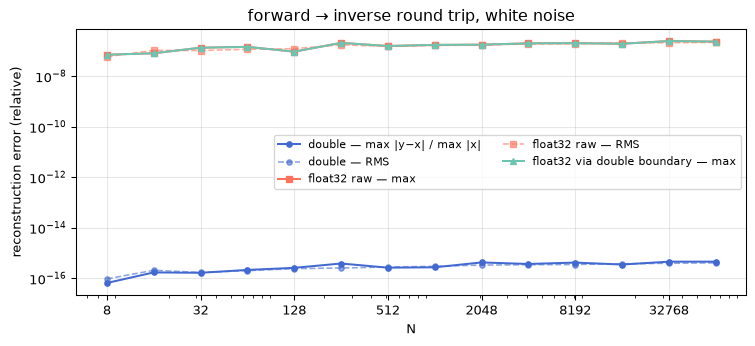

worst double round trip over all N: 4.57e-16; worst float32 raw: 2.45e-07
largest difference between the float profile's double-boundary and raw paths, any N: 0.0e+00


In [5]:
def roundtrip(N):
    x = rng.standard_normal(N)
    x32 = x.astype(np.float32)
    d = tap.RealFFT(N, "double")
    f = tap.RealFFT(N, "float")
    y_d = d.inverse(d.forward(x))
    y_fb = f.inverse(f.forward(x32.astype(np.float64)))            # float profile, double boundary
    buf = x32.copy(); f.forward_inplace_raw(buf); f.inverse_inplace_raw(buf)
    y_fr = buf * np.float32(2.0 / N)                                # float profile, raw, float32 scale
    def stats(y, ref):
        e = y.astype(np.float64) - ref.astype(np.float64)
        return np.max(np.abs(e)) / np.max(np.abs(ref)), np.linalg.norm(e) / np.linalg.norm(ref)
    return (*stats(y_d, x), *stats(y_fb, x32), *stats(y_fr, x32), np.max(np.abs(y_fb - y_fr)))

rt = np.array([(N, *roundtrip(N)) for N in SIZES])
print(f"{'N':>6} | {'double max':>10} {'double rms':>10} | {'f32/dbl max':>11} {'f32/dbl rms':>11} | {'f32 raw max':>11} {'f32 raw rms':>11}")
for r in rt:
    print(f"{int(r[0]):>6} | {r[1]:10.2e} {r[2]:10.2e} | {r[3]:11.2e} {r[4]:11.2e} | {r[5]:11.2e} {r[6]:11.2e}")

fig, ax = plt.subplots(figsize=(9, 3.6))
Ns = rt[:, 0]
ax.loglog(Ns, rt[:, 1], "o-", color=C[0], ms=4, lw=1.5, label="double — max |y−x| / max |x|")
ax.loglog(Ns, rt[:, 2], "o--", color=C[0], ms=4, lw=1.2, alpha=0.6, label="double — RMS")
ax.loglog(Ns, rt[:, 5], "s-", color=C[2], ms=4, lw=1.5, label="float32 raw — max")
ax.loglog(Ns, rt[:, 6], "s--", color=C[2], ms=4, lw=1.2, alpha=0.6, label="float32 raw — RMS")
ax.loglog(Ns, rt[:, 3], "^-", color=C[3], ms=4, lw=1.5, label="float32 via double boundary — max")
ax.set(xlabel="N", ylabel="reconstruction error (relative)", title="forward → inverse round trip, white noise",
       xticks=SIZES[::2], xticklabels=[str(s) for s in SIZES[::2]])
ax.legend(fontsize=8, ncol=2)
plt.show()
print(f"worst double round trip over all N: {rt[:, 1].max():.2e}; worst float32 raw: {rt[:, 5].max():.2e}")
print(f"largest difference between the float profile's double-boundary and raw paths, any N: {rt[:, 7].max():.1e}")

## 4 · Fixed point — Q15 and Q31 noise floors (Stage 3b/3c placeholder)

**No data yet.** `dsptap_fft_create` returns NULL for `DSPTAP_FFT_PROFILE_Q15`/`Q31` and
`RealFFT(n, "q15")` raises `NotImplementedError` until the fixed-point kernel of Stage 3b lands
(`docs/audit-fft-and-code-smells.md`, Part 7); Stage 3c wires the two profiles through this
ABI and fills this section. Recorded here so the measurement is designed before the kernel is,
and so nobody mistakes the section's absence for the profiles' absence.

**What will be measured, on the shipping C++ through the same `forward_inplace_raw` path used in
§2** (int16 / int32 buffers, no conversion):

- **Noise floor vs input level.** For each profile and each of the two scaling policies (fixed
  shift-per-stage, block floating point), a full-scale-referenced sine and white noise at input
  levels from −90 dBFS to 0 dBFS, N ∈ {256, 512, 2048}; the output compared bin for bin against
  the double golden model driven with the *same* quantized input, and the error power reported
  in dBFS. The curve of error vs level is the profile's noise floor; where it turns upward at the
  top of the range is the saturation-free input level the header will state as a number.
- **The model it is checked against.** Welch's fixed-point FFT error analysis (P. D. Welch, "A
  fixed-point fast Fourier transform error analysis," *IEEE Trans. Audio Electroacoust.*
  AU-17(2), 1969; summarized in Oppenheim & Schafer, *Discrete-Time Signal Processing*, ch. 9):
  each rounded butterfly injects white noise of variance ∝ 2^−2b; with a right shift by one at
  every stage the injected noise is attenuated by the remaining stages and the output
  noise-to-signal ratio grows roughly **as N** (half a bit per stage), whereas with no
  per-stage scaling — input pre-scaled by 1/N so nothing overflows — it grows **as N²** (a bit
  per stage). Block floating point sits between the two and depends on the signal's crest
  factor, which is why it is measured on material and not only on sines.
- **BFP exponent behaviour on speech-like material** — the distribution of the block exponent
  the BFP policy chooses per frame on a speech-shaped noise sequence and on real recordings, so
  a consumer knows how much headroom it is actually buying.
- **Cross-precision agreement.** The Q31 profile against double at a moderate level should sit
  near the float32 curve of §2 (24 effective bits vs 31), and Q15 roughly 48 dB above it; the
  measured gap is the number that goes into the README's profiles table.

The gates behind these plots are the fixed-point battery of Part 9, run on the hosts and on
the M4/M33/M55 QEMU legs; this notebook reports the same numbers as curves.

## Summary

- **Packing and sign** (§1): `fft.h`'s packed layout and exp(+i) convention hold exactly as
  documented; `RealFFT.unpack` (which conjugates) matches `numpy.fft.rfft` to double rounding
  (2.7e-15 at N = 64), and the raw imaginary parts are the mirror image of numpy's.
- **Float vs double** (§2): on white noise the float32 profile's RMS relative error against the
  golden model runs from 5.4e-8 at N = 8 to 1.5e-7 at N = 65536, growing as (log₂N)^0.6 — close
  to Weinstein's √log₂N and an order of magnitude under the ε₃₂·log₂N worst-case bound; the
  median per-bin error is the same size, the 95th percentile ~4x it. On numerically empty bins
  the per-bin relative error is meaningless (§2b: median ~1 against the exact-signal reference,
  and at bin 3 half the bins exceed 1e6), exactly as the header says; peak-normalized error
  there is 6e-8 to 1.2e-7.
- **Round trip** (§3): `inverse(forward(x))` reproduces the input to at most 4.6e-16 in double
  and 2.5e-7 in float32 (relative to the block's peak) over N = 8 … 65536; the float profile's
  double-boundary path is bit-identical to its raw path.
- **Fixed point** (§4): designed, not measured; lands with Stage 3b/3c.

Every number above is produced by the shipping C++ through `tools/capi` (this host: Linux,
Ooura for both profiles); the corresponding hard gates live in `tests/test_fft.cpp` and
`tests/test_fft_backend.cpp`, and the exact values are in the output cells above.